다음 데이터 세트를 이용하여 다이아몬드 가격예측(회귀) 

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv" diamonds = pd.read_csv(url) 

2. Dense layer만 이용 FNCC 구현

각 단계별로 수행완료후

검사받은 이후에 다음 단계 진행

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.isna().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [4]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [5]:
df.shape

(53940, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


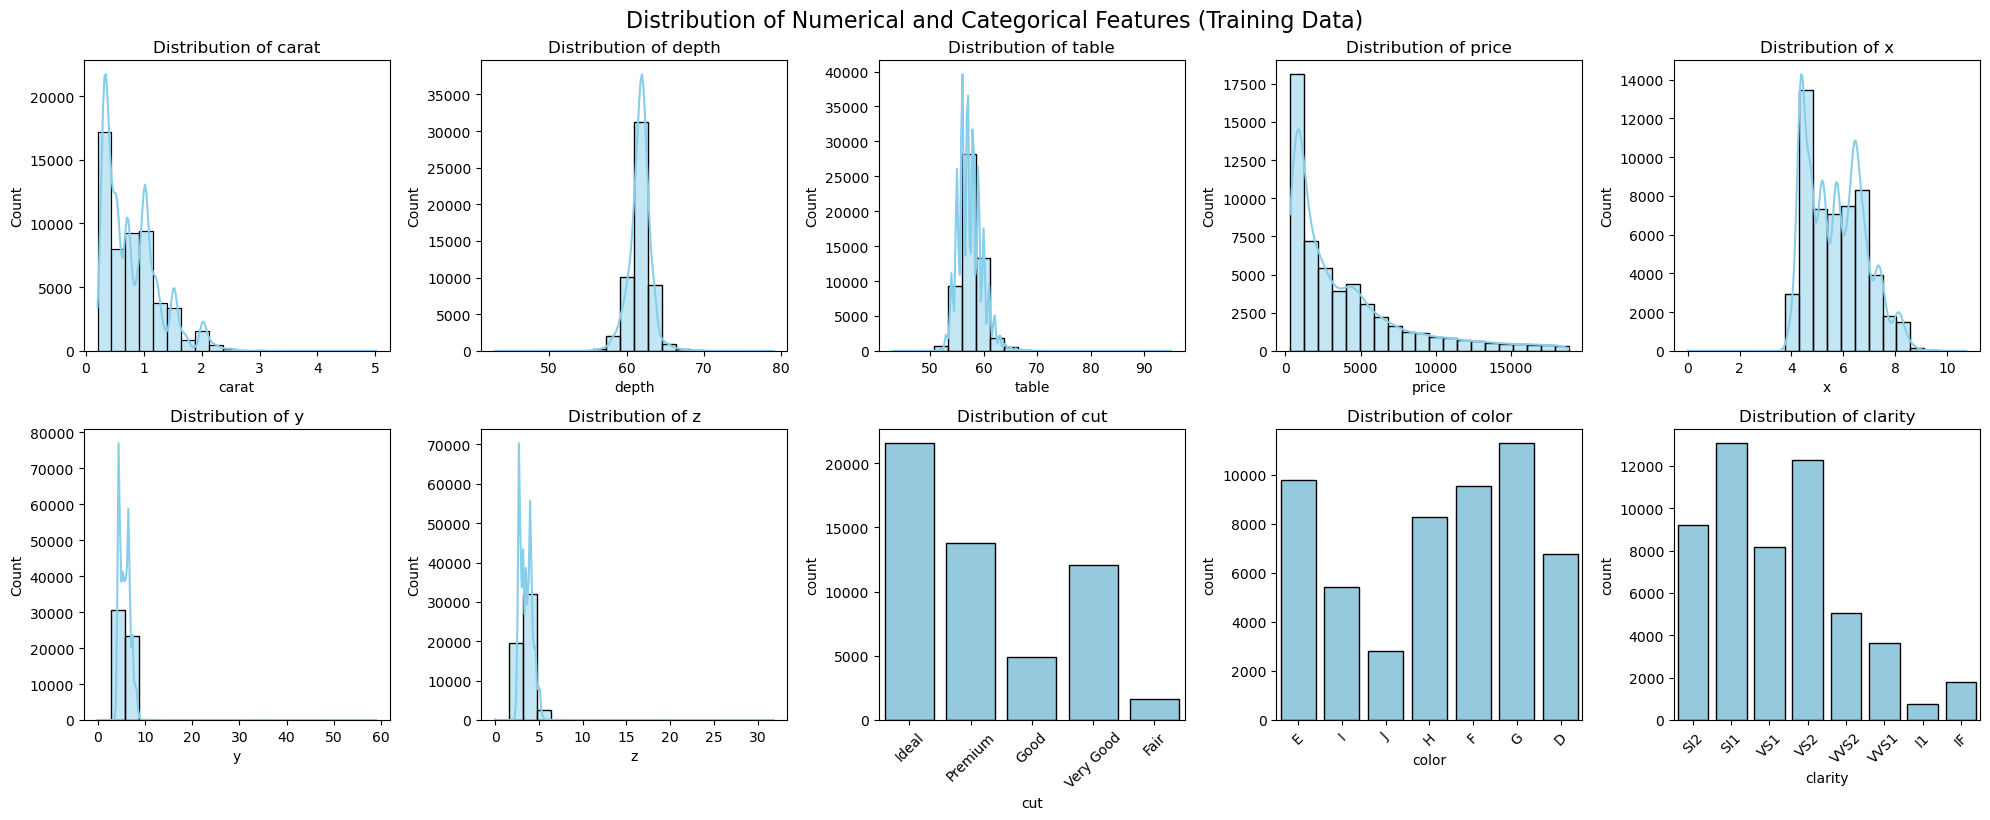

In [8]:
# Select numerical and categorical features
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

# Combine numerical and categorical features into a single list (assuming there are 9 total)
all_features = list(numerical_features) + list(categorical_features)

# Create a 3x3 grid plot for all features with the same color (skyblue)
plt.figure(figsize=(20, 8))  # Adjust figure size for a 3x3 grid

for i, feature in enumerate(all_features):
    plt.subplot(2, 5, i + 1)  # Create a 3x3 grid
    if feature in numerical_features:
        sns.histplot(df[feature], bins=20, kde=True, color='skyblue', edgecolor='black')
        plt.title(f'Distribution of {feature}')
    elif feature in categorical_features:
        sns.countplot(data=df, x=feature, color='skyblue', edgecolor='black')
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)

    plt.tight_layout()

plt.suptitle('Distribution of Numerical and Categorical Features (Training Data)', fontsize=16, y=1.02)
plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

df['cut'] = le1.fit_transform(df['cut'])
df['color'] = le2.fit_transform(df['color'])
df['clarity'] = le3.fit_transform(df['clarity'])

In [10]:
# Create Target
x = df.drop(['price'], axis=1)
y = df['price']

In [11]:
# Train-Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)

In [12]:
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense

# DNN Model
inputs = Input(shape=(9,))

# Dense Layers
dense1 = Dense(128, activation='relu')(inputs)
dense2 = Dense(64, activation='relu')(dense1)
dense3 = Dense(32, activation='relu')(dense2)

# Output Layer
outputs = Dense(1)(dense3)

# Compile Model
dnn_model = keras.Model(inputs=inputs, outputs=outputs)
dnn_model.compile(optimizer='adam', loss='mse', metrics=['mse'])
dnn_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 9)]               0         
                                                                 
 dense (Dense)               (None, 128)               1280      
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                                 
Total params: 11,649
Trainable params: 11,649
Non-trainable params: 0
_________________________________________________________________


In [13]:
# Early Stopping Callback
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)

# Fit Model
dnn_history = dnn_model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stopping_cb])
     

Epoch 1/50


2024-10-24 09:33:35.915884: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


1079/1079 [==============================] - 1s 526us/step - loss: 13355286.0000 - mse: 13355286.0000 - val_loss: 3378965.0000 - val_mse: 3378965.0000
Epoch 2/50
1079/1079 [==============================] - 0s 403us/step - loss: 1709942.5000 - mse: 1709942.5000 - val_loss: 1337902.8750 - val_mse: 1337902.8750
Epoch 3/50
1079/1079 [==============================] - 0s 415us/step - loss: 1358868.3750 - mse: 1358868.3750 - val_loss: 1221041.7500 - val_mse: 1221041.7500
Epoch 4/50
1079/1079 [==============================] - 0s 386us/step - loss: 1316640.7500 - mse: 1316640.7500 - val_loss: 1184874.5000 - val_mse: 1184874.5000
Epoch 5/50
1079/1079 [==============================] - 0s 430us/step - loss: 1305727.0000 - mse: 1305727.0000 - val_loss: 1186860.1250 - val_mse: 1186860.1250
Epoch 6/50
1079/1079 [==============================] - 0s 462us/step - loss: 1288557.7500 - mse: 1288557.7500 - val_loss: 1204131.8750 - val_mse: 1204131.8750
Epoch 7/50
1079/1079 [===========================

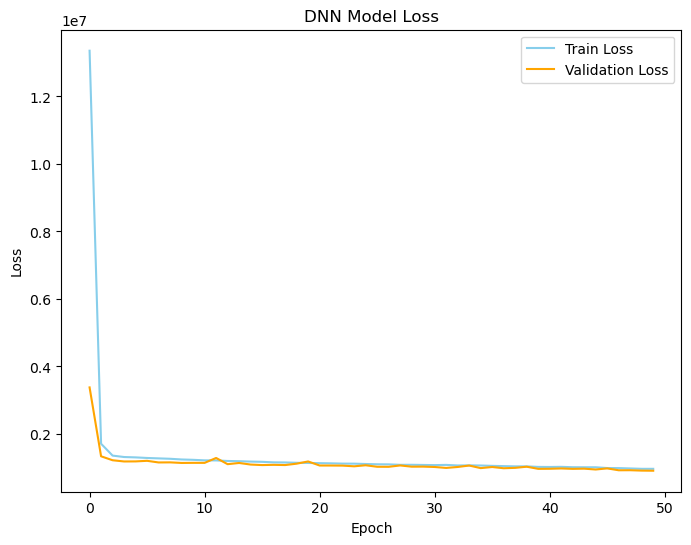

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

# Loss Plot
plt.plot(dnn_history.history['loss'], label='Train Loss', color='skyblue')
plt.plot(dnn_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('DNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()